# Imports

In [6]:
import sys
sys.path.insert(0, '.')
from pathlib import Path

import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image

from src.ingest import download_price_data_by_year, load_price_data, fetch_weather, merge_price_and_weather
from src.features import build_feature_matrix, chronological_split
from src.model import train_lgbm, compare_models, get_feature_importance
from src.visualize import plot_actual_vs_predicted, plot_feature_importance

# Data Download

In [7]:
OUTPUT_PATH = Path.cwd() / "data" / "sample_pjm_lmp.csv"

years = [2022, 2023]
frames = [download_price_data_by_year(y) for y in years]
combined = pd.concat(frames, ignore_index=True)
combined.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(combined):,} rows to {OUTPUT_PATH}")

Saved 16,320 rows to /home/roberto/Documents/portfolio_projects/EnergyMarket/ElectricityPricePrediction/data/sample_pjm_lmp.csv


# Data Loading

In [8]:
# Load prices from the bundled sample CSV (2022-2023 PJM APS zone)
prices = load_price_data('data/sample_pjm_lmp.csv')
print(f"Price data: {len(prices):,} hourly observations")
print(f"Date range: {prices.index.min()} → {prices.index.max()}")
prices.head()

Price data: 16,320 hourly observations
Date range: 2022-01-01 01:00:00-05:00 → 2024-01-01 00:00:00-05:00


,lmp_usd_mwh
datetime_et,
2022-01-01 01:00:00-05:00,20.997218
2022-01-01 02:00:00-05:00,18.123202
2022-01-01 03:00:00-05:00,17.837826
2022-01-01 04:00:00-05:00,17.876213
2022-01-01 05:00:00-05:00,17.481340


In [9]:
# Fetch hourly temperature for Philadelphia from Open-Meteo (no API key needed)
weather = fetch_weather('2022-01-01', '2023-12-31')
print(f"Weather data: {len(weather):,} hourly observations")
weather.head()

Weather data: 17,518 hourly observations


,temperature_2m
datetime_et,
2022-01-01 00:00:00-05:00,48.0
2022-01-01 01:00:00-05:00,48.7
2022-01-01 02:00:00-05:00,48.6
2022-01-01 03:00:00-05:00,48.7
2022-01-01 04:00:00-05:00,49.3


In [10]:
# Merge on the shared Eastern-time DatetimeIndex
df = merge_price_and_weather(prices, weather)
print(f"Merged dataset: {len(df):,} rows | Missing weather: {df['temperature_2m'].isna().sum()}")
df.describe().round(2)

Merged dataset: 16,322 rows | Missing weather: 0


,lmp_usd_mwh,temperature_2m
count,16322.00,16322.00
mean,55.03,55.15
std,36.77,17.32
min,10.01,1.30
25%,30.64,41.70
50%,45.14,54.80
75%,67.87,69.00
max,480.88,97.30


In [11]:
df.head(5)

,lmp_usd_mwh,temperature_2m
datetime_et,,
2022-01-01 01:00:00-05:00,20.997218,48.7
2022-01-01 02:00:00-05:00,18.123202,48.6
2022-01-01 03:00:00-05:00,17.837826,48.7
2022-01-01 04:00:00-05:00,17.876213,49.3
2022-01-01 05:00:00-05:00,17.481340,49.9


# Data Exploration

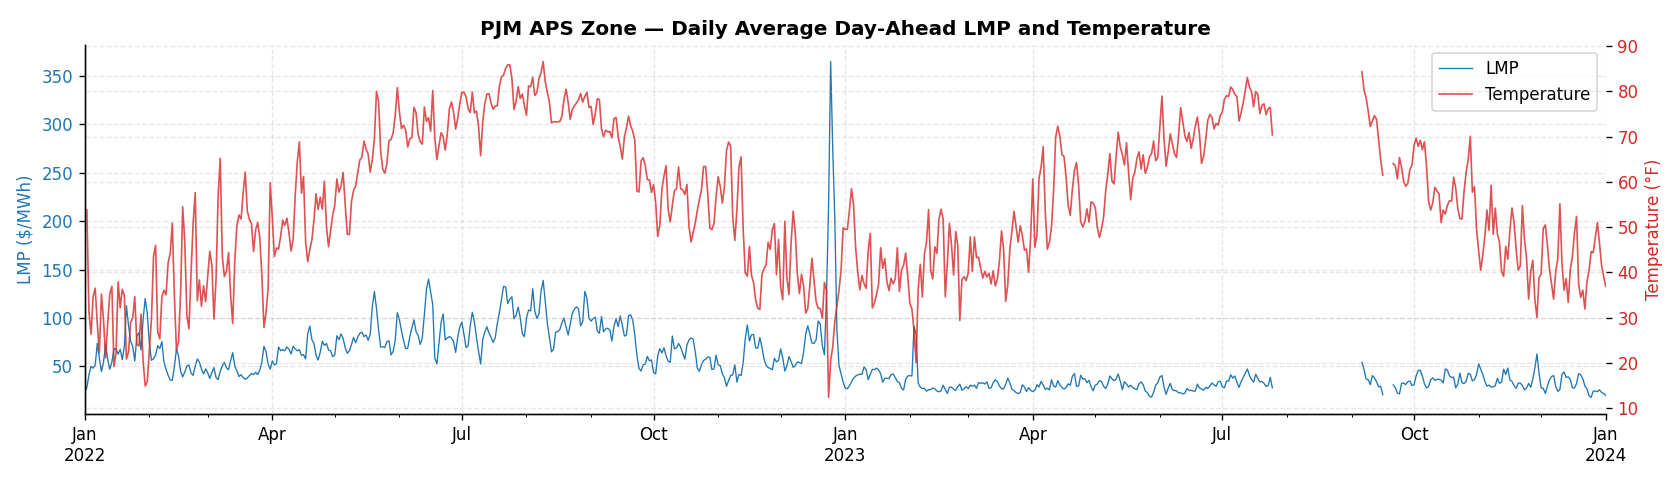

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 4))

# Daily average LMP (left axis)
df["lmp_usd_mwh"].resample("D").mean().plot(ax=ax1, linewidth=0.8, color="tab:blue", label="LMP")
ax1.set_title("PJM APS Zone — Daily Average Day-Ahead LMP and Temperature", fontsize=12, fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("LMP ($/MWh)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)
ax1.spines[["top"]].set_visible(False)

# Secondary axis for temperature
ax2 = ax1.twinx()
df["temperature_2m"].resample("D").mean().plot(ax=ax2, linewidth=1.0, color="tab:red", alpha=0.8, label="Temperature")
ax2.set_ylabel("Temperature (°F)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.spines["top"].set_visible(False)

# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.savefig("outputs/figures/raw_price_temperature_history.png", dpi=120)
plt.close()

Image("outputs/figures/raw_price_temperature_history.png")

Some observations:
- Seasonality is clearly shown by the temperature. Max in August 2022 and 2023. Min in January 2022 and 2023.
- Large spike close to Jan 2023. Is this driven by the lowest temperature in the range? Were more expensive sources of energy used? i.e. Oil-Diesel?
- LMPs decreases considerably from 2022 going into 2023. Why? Where there major changes in the infrastructure? Where there government subsidies?

# Feature Engineering

In [14]:
X, y = build_feature_matrix(df)  # adds features

# Chronological ~80/20 split: train on ~21 months, test on Q4 2023
X_train, X_test, y_train, y_test, split_date = chronological_split(X, y, test_months=3)

print(f"Training set : {X_train.index.min().date()} → {X_train.index.max().date()} ({len(X_train):,} hours)")
print(f"Test set     : {X_test.index.min().date()} → {X_test.index.max().date()} ({len(X_test):,} hours)")
X_train.head(3)

Training set : 2022-01-08 → 2023-10-01 (13,969 hours)
Test set     : 2023-10-01 → 2024-01-01 (2,185 hours)


,hour_of_day,day_of_week,month,is_weekend,temperature_2m,price_lag_24h,price_lag_48h,price_lag_168h,price_roll_7d_mean
datetime_et,,,,,,,,,
2022-01-08 01:00:00-05:00,1,5,1,1,21.0,47.049481,40.227834,20.997218,45.513071
2022-01-08 02:00:00-05:00,2,5,1,1,20.5,45.650191,38.965792,18.123202,45.808550
2022-01-08 03:00:00-05:00,3,5,1,1,20.1,45.379750,38.410574,17.837826,46.110935


# Model Training

In [15]:
model = train_lgbm(X_train, y_train)
print(f"Model trained on {len(X_train):,} observations with {X_train.shape[1]} features.")

Model trained on 13,969 observations with 9 features.


# Evaluation

Performance is measured on the **out-of-sample Q4 2023 test period** — data the model has never seen.

**Naïve benchmark**: predict each hour's price = the price at the same hour yesterday (T-24h). This is a strong baseline in electricity markets because prices are highly autocorrelated at the 24-hour lag.

In [16]:
results, lgbm_preds, naive_preds = compare_models(model, X_test, y_train, y_test)
results

,MAE,RMSE
Model,,
LightGBM,7.65,10.31
Naive (T-24h),6.90,11.02


# Visualizations

- Actual vs Predicted prices (14-day test window)
- Feature importance ranking

Saved: outputs/figures/actual_vs_predicted.png


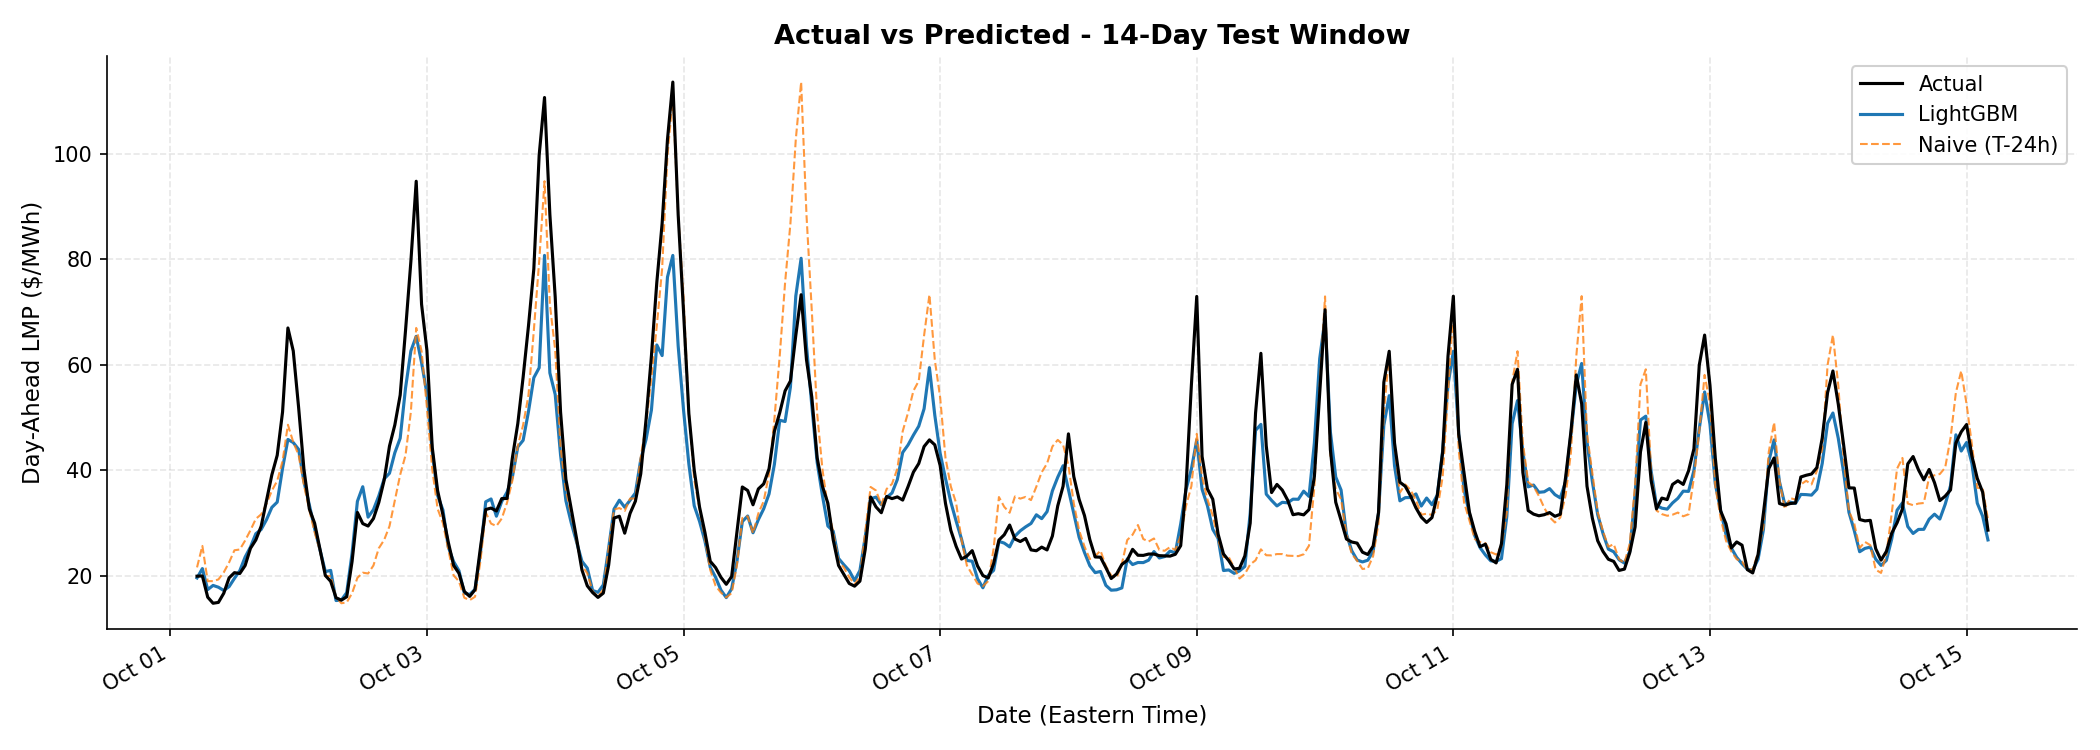

In [18]:
plot_actual_vs_predicted(
    y_test, lgbm_preds, naive_preds,
    window_days=14,
    output_path='outputs/figures/actual_vs_predicted.png'
)

Image('outputs/figures/actual_vs_predicted.png')

Saved: outputs/figures/feature_importance.png


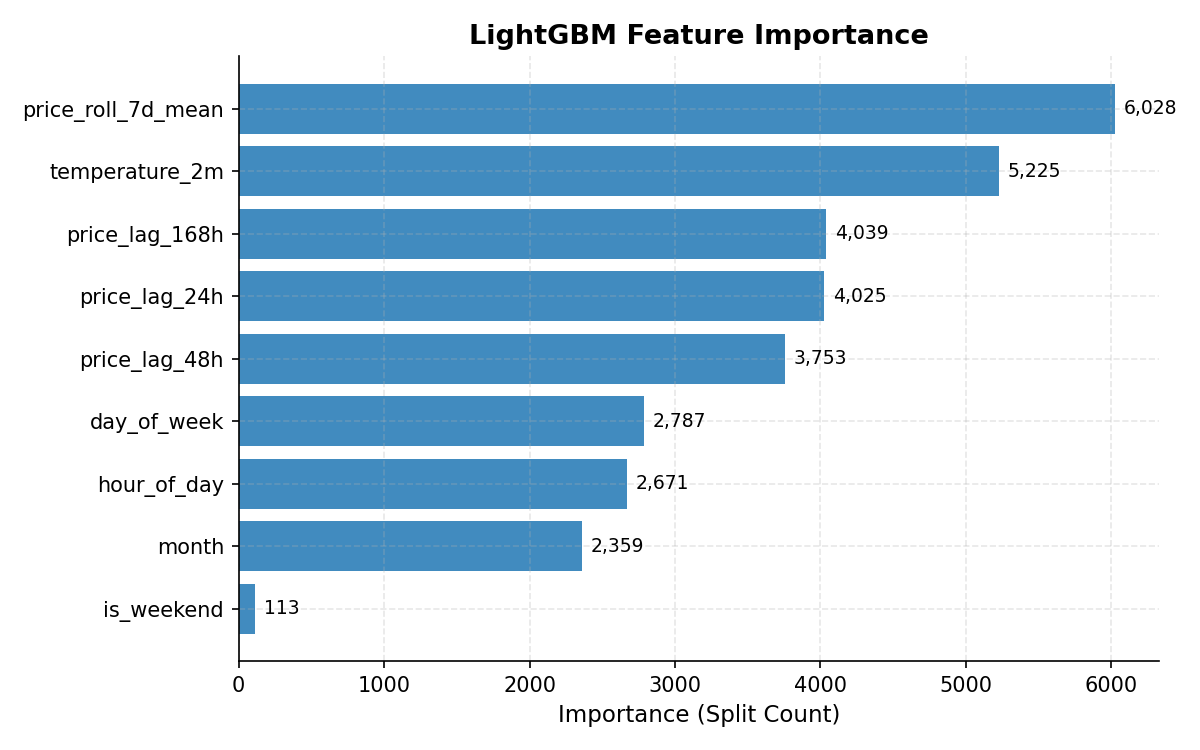

In [19]:
plot_feature_importance(
    importance_df,
    output_path='outputs/figures/feature_importance.png'
)

Image('outputs/figures/feature_importance.png')

# Conclusions

- LightGBM achieves lower **RMSE** than the naïve benchmark, meaning it better controls large forecast errors during price spikes.
- The naïve benchmark is competitive on MAE — expected in electricity markets where the 24-hour autocorrelation is very strong.
- RMSE improvement (~7%) demonstrates real model value for risk-sensitive applications (hedging, dispatch) where peak errors are costly.
